In [120]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import preprocessing
from sklearn import metrics
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,LSTM,Bidirectional
from tensorflow.keras.callbacks import EarlyStopping

In [121]:
data = pd.read_csv("AAPL.csv")
data

,Date,Close/Last,Volume,Open,High,Low
0,02/28/2020,$273.36,106721200,$257.26,$278.41,$256.37
1,02/27/2020,$273.52,80151380,$281.1,$286,$272.96
2,02/26/2020,$292.65,49678430,$286.53,$297.88,$286.5
3,02/25/2020,$288.08,57668360,$300.95,$302.53,$286.13
4,02/24/2020,$298.18,55548830,$297.26,$304.18,$289.23
...,...,...,...,...,...,...
2513,03/05/2010,$31.2786,224647427,$30.7057,$31.3857,$30.6614
2514,03/04/2010,$30.1014,89591907,$29.8971,$30.1314,$29.8043
2515,03/03/2010,$29.9043,92846488,$29.8486,$29.9814,$29.7057
2516,03/02/2010,$29.8357,141486282,$29.99,$30.1186,$29.6771


In [122]:
data.tail(10)

,Date,Close/Last,Volume,Open,High,Low
2508,03/12/2010,$32.3714,103841951,$32.4814,$32.5328,$32.25
2509,03/11/2010,$32.2143,101209110,$31.9871,$32.2143,$31.9028
2510,03/10/2010,$32.12,148907755,$31.9757,$32.2114,$31.8857
2511,03/09/2010,$31.86,229908139,$31.1871,$32.1428,$31.1271
2512,03/08/2010,$31.2971,107326832,$31.43,$31.4414,$31.1786
2513,03/05/2010,$31.2786,224647427,$30.7057,$31.3857,$30.6614
2514,03/04/2010,$30.1014,89591907,$29.8971,$30.1314,$29.8043
2515,03/03/2010,$29.9043,92846488,$29.8486,$29.9814,$29.7057
2516,03/02/2010,$29.8357,141486282,$29.99,$30.1186,$29.6771
2517,03/01/2010,$29.8557,137312041,$29.3928,$29.9286,$29.35


In [123]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2518 entries, 0 to 2517
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Date         2518 non-null   object
 1    Close/Last  2518 non-null   object
 2    Volume      2518 non-null   int64 
 3    Open        2518 non-null   object
 4    High        2518 non-null   object
 5    Low         2518 non-null   object
dtypes: int64(1), object(5)
memory usage: 118.2+ KB


In [124]:
data[" Close/Last"] = data[" Close/Last"].str.replace("$","").astype("float")
data[" Open"] = data[" Open"].str.replace("$","").astype("float")
data[" High"] = data[" High"].str.replace("$","").astype("float")
data[" Low"] = data[" Low"].str.replace("$","").astype("float")
data.dtypes

Date            object
 Close/Last    float64
 Volume          int64
 Open          float64
 High          float64
 Low           float64
dtype: object

In [125]:
data["Date"] = pd.to_datetime(data["Date"],format="%m/%d/%Y")
data.dtypes

Date           datetime64[ns]
 Close/Last           float64
 Volume                 int64
 Open                 float64
 High                 float64
 Low                  float64
dtype: object

In [126]:
data

,Date,Close/Last,Volume,Open,High,Low
0,2020-02-28,273.3600,106721200,257.2600,278.4100,256.3700
1,2020-02-27,273.5200,80151380,281.1000,286.0000,272.9600
2,2020-02-26,292.6500,49678430,286.5300,297.8800,286.5000
3,2020-02-25,288.0800,57668360,300.9500,302.5300,286.1300
4,2020-02-24,298.1800,55548830,297.2600,304.1800,289.2300
...,...,...,...,...,...,...
2513,2010-03-05,31.2786,224647427,30.7057,31.3857,30.6614
2514,2010-03-04,30.1014,89591907,29.8971,30.1314,29.8043
2515,2010-03-03,29.9043,92846488,29.8486,29.9814,29.7057
2516,2010-03-02,29.8357,141486282,29.9900,30.1186,29.6771


In [127]:
data = data.sort_values("Date").reset_index(drop=True)
data

,Date,Close/Last,Volume,Open,High,Low
0,2010-03-01,29.8557,137312041,29.3928,29.9286,29.3500
1,2010-03-02,29.8357,141486282,29.9900,30.1186,29.6771
2,2010-03-03,29.9043,92846488,29.8486,29.9814,29.7057
3,2010-03-04,30.1014,89591907,29.8971,30.1314,29.8043
4,2010-03-05,31.2786,224647427,30.7057,31.3857,30.6614
...,...,...,...,...,...,...
2513,2020-02-24,298.1800,55548830,297.2600,304.1800,289.2300
2514,2020-02-25,288.0800,57668360,300.9500,302.5300,286.1300
2515,2020-02-26,292.6500,49678430,286.5300,297.8800,286.5000
2516,2020-02-27,273.5200,80151380,281.1000,286.0000,272.9600


In [128]:
data.describe().T

,count,mean,min,25%,50%,75%,max,std
Date,2518,2015-02-26 15:01:17.204130304,2010-03-01 00:00:00,2012-08-24 18:00:00,2015-02-28 12:00:00,2017-08-27 06:00:00,2020-02-28 00:00:00,NaN
Close/Last,2518.0,114.769522,29.8357,66.822475,101.09,154.63,327.2,60.662405
Volume,2518.0,72580094.262113,11362050.0,30530265.0,52954690.0,98610062.5,462442329.0,56631126.108815
Open,2518.0,114.728443,29.3928,66.87715,101.115,154.61,324.74,60.546893
High,2518.0,115.766415,29.9286,67.4753,102.085,155.735,327.85,61.134456
Low,2518.0,113.690582,28.4643,66.37295,100.35,153.325,323.35,60.085105


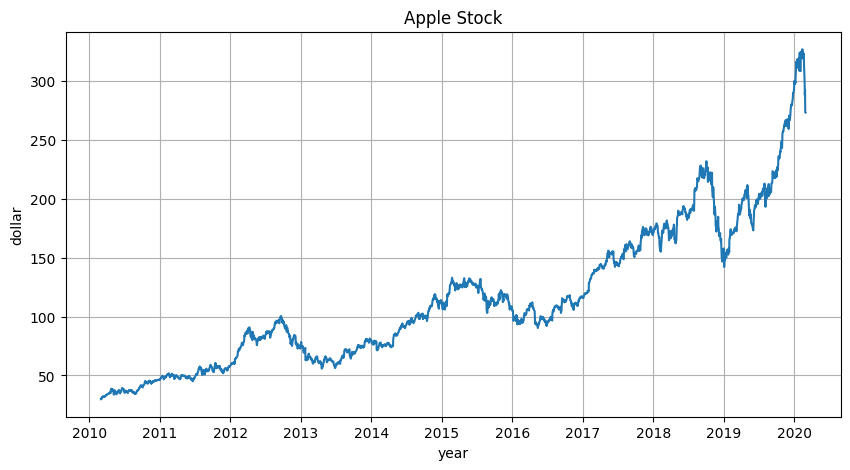

In [129]:
plt.figure(figsize=(10,5))
plt.plot(data["Date"],data[" Close/Last"])
plt.xlabel("year")
plt.ylabel("dollar")
plt.title("Apple Stock")
plt.grid()
plt.show()

In [130]:
scaler = preprocessing.MinMaxScaler()
data[" Close/Last"] = scaler.fit_transform(data[[" Close/Last"]])

In [131]:
len(data)

2518

In [132]:
x = []
y = []
window_size = 50
for i in range(len(data) - window_size):
    x.append(data[" Close/Last"][i:i+window_size])
    y.append(data[" Close/Last"][i+window_size])
x = np.array(x)
y = np.array(y)
x.shape, y.shape

((2468, 50), (2468,))

In [133]:
int(2468 * 0.8)

1974

In [134]:
split = int(2468 * 0.8)

x_train = x[:split]
x_test = x[split:]

y_train = y[:split]
y_test = y[split:]

x_train.shape, x_test.shape, y_train.shape, y_test.shape

((1974, 50), (494, 50), (1974,), (494,))

In [135]:
early_stopping = EarlyStopping(monitor="val_loss",
                               patience=3,
                               restore_best_weights = True)

In [136]:
x_train[0].shape

(50,)

In [137]:
model = Sequential()
model.add(LSTM(64,activation="relu",input_shape=(50,1)))
model.add(Dense(1,activation="linear"))
model.summary()

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_5 (LSTM)                   │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,961 (66.25 KB)

 Trainable params: 16,961 (66.25 KB)

 Non-trainable params: 0 (0.00 B)

In [138]:
model.compile(optimizer="adam",loss="mae")

In [139]:
hist = model.fit(x_train,y_train,
          epochs=40,
          validation_data=(x_test,y_test),
          callbacks = [early_stopping],
          batch_size=50)

Epoch 1/40
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0639 - val_loss: 0.1256
Epoch 2/40
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0131 - val_loss: 0.0852
Epoch 3/40
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0089 - val_loss: 0.0293
Epoch 4/40
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0075 - val_loss: 0.0276
Epoch 5/40
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0075 - val_loss: 0.0197
Epoch 6/40
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0074 - val_loss: 0.0191
Epoch 7/40
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0070 - val_loss: 0.0179
Epoch 8/40
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0069 - val_loss: 0.0178
Epoch 9/40
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0073 - val_loss: 0.0173
Epoch 10/40
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0069 - val_loss: 0.0181
Epoch 11/40
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0065 - val_loss: 0.0195
Epoch 12/40
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0

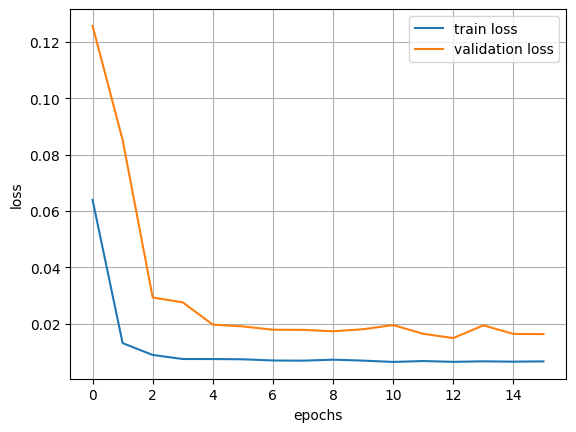

In [140]:
plt.plot(hist.history["loss"],label="train loss")
plt.plot(hist.history["val_loss"],label="validation loss")
plt.xlabel("epochs")
plt.ylabel("loss")
plt.legend()
plt.grid()
plt.show()

In [141]:
y_test.reshape(-1, 1)

array([[0.4997382 ],
       [0.5004444 ],
       [0.49832579],
       [0.48917876],
       [0.48897699],
       [0.47562636],
       [0.4674882 ],
       [0.45433934],
       [0.48067068],
       [0.46577313],
       [0.45951817],
       [0.46388992],
       [0.46019075],
       [0.46594127],
       [0.47676974],
       [0.48077157],
       [0.46590764],
       [0.47152365],
       [0.48228486],
       [0.47956093],
       [0.48527782],
       [0.48726192],
       [0.49092746],
       [0.49906562],
       [0.49772047],
       [0.48077157],
       [0.45696239],
       [0.4553482 ],
       [0.44761358],
       [0.45000123],
       [0.45191807],
       [0.4455286 ],
       [0.45541546],
       [0.46832892],
       [0.49344962],
       [0.49452574],
       [0.51786411],
       [0.52233674],
       [0.52532971],
       [0.52973508],
       [0.53874759],
       [0.53387142],
       [0.53239175],
       [0.52664123],
       [0.53249264],
       [0.52849081],
       [0.52620405],
       [0.530

In [142]:
y_pred = model.predict(x_test)
y_pred_descale = scaler.inverse_transform(y_pred)

y_test_descale = scaler.inverse_transform(y_test.reshape(-1, 1))

mae_scale = metrics.mean_absolute_error(y_test,y_pred)
mae_real = metrics.mean_absolute_error(y_test_descale,y_pred_descale)

print("میزان خطای اسکیل شده :",mae_scale)
print("میزان خطای واقعی به دلار :",mae_real)

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
میزان خطای اسکیل شده : 0.014941688455469036
میزان خطای واقعی به دلار : 4.443126903950927


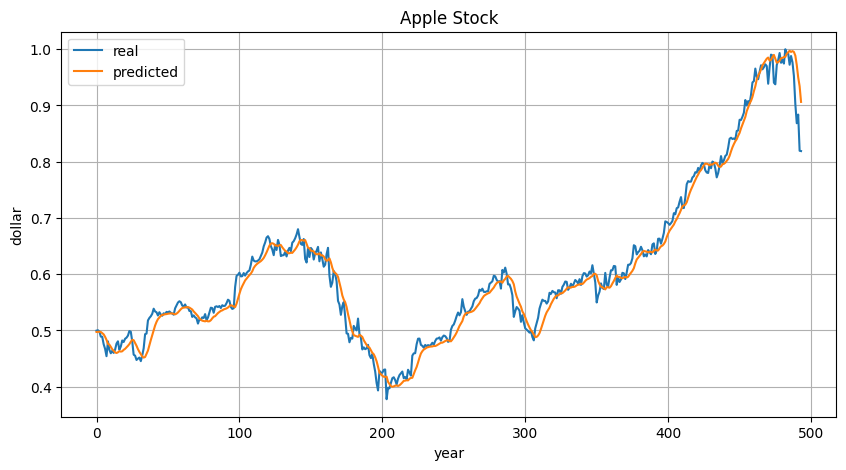

In [143]:
plt.figure(figsize=(10,5))
plt.plot(y_test,label="real")
plt.plot(y_pred,label="predicted")
plt.legend()
plt.xlabel("year")
plt.ylabel("dollar")
plt.title("Apple Stock")
plt.grid()
plt.show()


In [144]:
data[" Close/Last"][-window_size:].values

array([0.84265092, 0.84039779, 0.84133939, 0.83938892, 0.85472365,
       0.85563163, 0.87459826, 0.87422835, 0.8800125 , 0.88717543,
       0.90970671, 0.89988711, 0.90785713, 0.90311547, 0.91925729,
       0.94091423, 0.94326824, 0.96556412, 0.951171  , 0.94666475,
       0.95977997, 0.97151642, 0.9642526 , 0.96805265, 0.97319786,
       0.97010401, 0.93862747, 0.96801903, 0.99038217, 0.98880161,
       0.94051068, 0.93765223, 0.97191996, 0.98066345, 0.99330787,
       0.97588816, 0.98099974, 0.97447575, 1.        , 0.99216449,
       0.99243352, 0.9724244 , 0.9879609 , 0.97679614, 0.95241527,
       0.90240927, 0.86844419, 0.88381255, 0.81948068, 0.81894262])